In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
df = pd.read_csv("09-iris.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

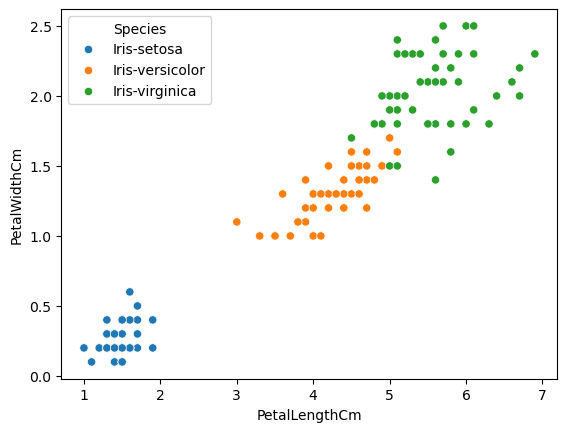

In [5]:
sns.scatterplot(x=df["PetalLengthCm"], y= df["PetalWidthCm"], hue=df["Species"])
plt.show()

In [6]:
df = df.drop("Id", axis=1) 

In [7]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]].values
y = df["Species"].values

In [9]:
from sklearn.preprocessing import LabelEncoder


In [10]:
le = LabelEncoder()
y = le.fit_transform(y)

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

In [13]:
y_train

array([0, 2, 1, 0, 1, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 0, 0, 2, 2, 0, 1, 0,
       2, 0, 1, 2, 2, 0, 2, 0, 0, 1, 1, 0, 2, 2, 1, 1, 2, 1, 0, 1, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 1, 2, 1, 0, 2, 1, 2, 0, 2, 0, 1, 2, 0, 1, 1,
       2, 1, 1, 2, 0, 0, 0, 2, 1, 2, 1, 2, 2, 1, 0, 2, 1, 0, 2, 0, 2, 1,
       1, 0, 1, 2, 0, 0, 2, 2, 2, 1, 2, 0, 2, 1, 2, 2, 0, 1, 1, 1, 1, 1,
       0, 2, 1, 1, 0, 0, 0, 0, 1, 0])

In [14]:
y_test

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 2, 2, 1, 1, 0, 2, 0])

In [15]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [16]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([120, 4]) torch.Size([120])
torch.Size([30, 4]) torch.Size([30])


In [17]:
from torch import nn

In [18]:
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features = 4, out_features=16)
        self.layer_2 = nn.Linear(in_features = 16, out_features=16)
        self.layer_3 = nn.Linear(in_features = 16, out_features=3)
        self.relu = ReLU()
    def forward(self,x):
        return self.leyer_3(self.layer_2(self.relu(self.layer_1(x))))

In [19]:
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer_stack = nn.Sequential(
            nn.Linear(4,16),
            nn.ReLU(),
            nn.Linear(16,16),
            nn.ReLU(),
            nn.Linear(16,3)
        )
    def forward(self,x):
        return self.linear_layer_stack(x)

In [20]:
model = IrisClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [21]:
def calculate_accuracy(y_test, y_pred):
    correct = torch.eq(y_test,y_pred).sum().item()
    accuracy = (correct / len(y_test)) *100
    return accuracy

In [22]:
y_logits = model(X_test)
y_pred_probs = torch.softmax(y_logits, dim= 1) 

In [23]:
epochs = 200

train_losses = []
test_losses = []
train_accs = []
test_accs = []

for epoch in range(epochs):
    model.train()
    logits = model(X_train)
    loss = loss_fn(logits, y_train)

    pred = torch.softmax(logits,dim=1).argmax(dim=1)
    acc = calculate_accuracy(y_train,pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    train_accs.append(acc)

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        test_acc = calculate_accuracy(y_test,test_pred)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    if epoch % 20 ==0:
        print(f"Epoch: {epoch}, Loss: {loss}, Accuracy: {acc}, Test Loss: {test_loss}, Test Accuracy: {test_acc}")


Epoch: 0, Loss: 1.111806869506836, Accuracy: 33.33333333333333, Test Loss: 1.0681591033935547, Test Accuracy: 33.33333333333333
Epoch: 20, Loss: 0.36094504594802856, Accuracy: 95.83333333333334, Test Loss: 0.3437724709510803, Test Accuracy: 96.66666666666667
Epoch: 40, Loss: 0.08488436043262482, Accuracy: 97.5, Test Loss: 0.08235086500644684, Test Accuracy: 100.0
Epoch: 60, Loss: 0.059290241450071335, Accuracy: 98.33333333333333, Test Loss: 0.04565196484327316, Test Accuracy: 100.0
Epoch: 80, Loss: 0.05503196269273758, Accuracy: 98.33333333333333, Test Loss: 0.040626585483551025, Test Accuracy: 100.0
Epoch: 100, Loss: 0.05219193547964096, Accuracy: 98.33333333333333, Test Loss: 0.04120743274688721, Test Accuracy: 100.0
Epoch: 120, Loss: 0.04992577061057091, Accuracy: 98.33333333333333, Test Loss: 0.03979573771357536, Test Accuracy: 100.0
Epoch: 140, Loss: 0.04828111454844475, Accuracy: 98.33333333333333, Test Loss: 0.044313494116067886, Test Accuracy: 100.0
Epoch: 160, Loss: 0.04662517

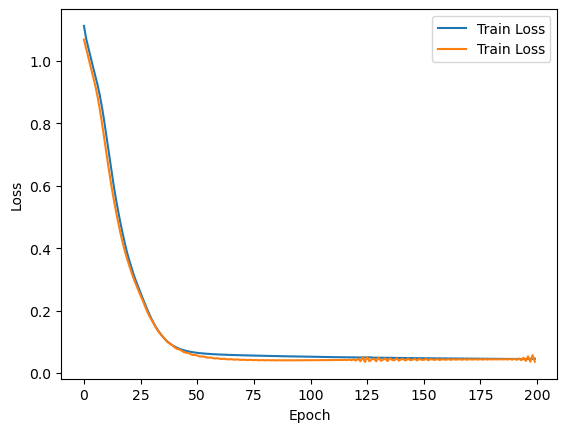

In [24]:
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

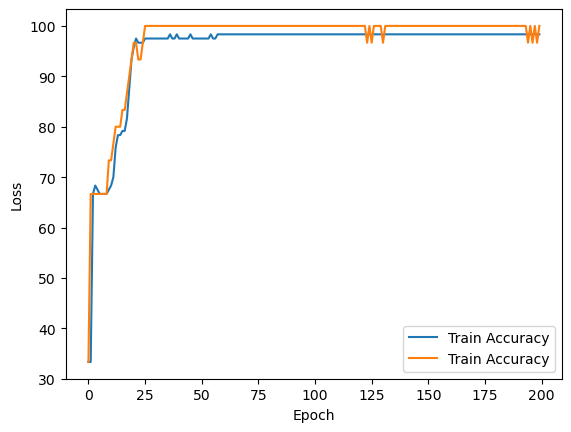

In [25]:
plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [26]:
from torchmetrics.classification import MulticlassAccuracy

In [27]:
accuracy = MulticlassAccuracy(num_classes = 3)

In [28]:
model2 = IrisClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=0.01)

In [29]:
epochs = 200

for epoch in range(epochs):
    model2.train()
    logits = model2(X_train)
    loss = loss_fn(logits, y_train)

    pred = torch.softmax(logits,dim=1).argmax(dim=1)
    acc =accuracy(pred,y_train).item() * 100

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    train_accs.append(acc)

    model2.eval()
    with torch.inference_mode():
        test_logits = model2(X_test)
        test_loss = loss_fn(test_logits, y_test)
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        test_acc = accuracy(test_pred,y_test).item() * 100

    if epoch % 20 ==0:
        print(f"Epoch: {epoch}, Loss: {loss}, Accuracy: {acc}, Test Loss: {test_loss}, Test Accuracy: {test_acc}")


Epoch: 0, Loss: 1.1872221231460571, Accuracy: 33.33333432674408, Test Loss: 1.1431678533554077, Test Accuracy: 33.33333432674408
Epoch: 20, Loss: 0.6644439697265625, Accuracy: 66.66666865348816, Test Loss: 0.6218202710151672, Test Accuracy: 66.66666865348816
Epoch: 40, Loss: 0.30872851610183716, Accuracy: 96.66666984558105, Test Loss: 0.30073055624961853, Test Accuracy: 100.0
Epoch: 60, Loss: 0.09249289333820343, Accuracy: 97.50000238418579, Test Loss: 0.09895487129688263, Test Accuracy: 100.0
Epoch: 80, Loss: 0.06297753751277924, Accuracy: 98.33333492279053, Test Loss: 0.05986873805522919, Test Accuracy: 100.0
Epoch: 100, Loss: 0.05717496946454048, Accuracy: 98.33333492279053, Test Loss: 0.0501047782599926, Test Accuracy: 100.0
Epoch: 120, Loss: 0.054191555827856064, Accuracy: 98.33333492279053, Test Loss: 0.04595610126852989, Test Accuracy: 100.0
Epoch: 140, Loss: 0.05195736885070801, Accuracy: 98.33333492279053, Test Loss: 0.044413331896066666, Test Accuracy: 100.0
Epoch: 160, Loss:

In [30]:
from torchmetrics.classification import MulticlassConfusionMatrix

In [31]:
cm= MulticlassConfusionMatrix(num_classes = 3)

In [32]:
matrix = cm(test_pred, y_test)

In [33]:
print(matrix)

tensor([[10,  0,  0],
        [ 0, 10,  0],
        [ 0,  0, 10]])


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

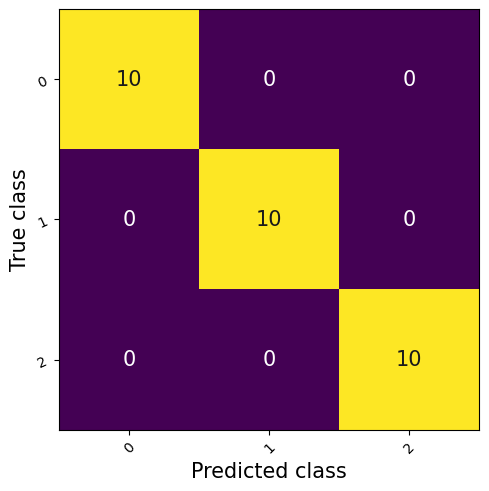

In [34]:
from torchmetrics.utilities.plot import plot_confusion_matrix
plot_confusion_matrix(matrix)

In [41]:
from pathlib import Path

In [42]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "iris_classification_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model2.state_dict(), f=MODEL_SAVE_PATH)

In [43]:
model2.state_dict()

OrderedDict([('linear_layer_stack.0.weight',
              tensor([[-0.2502, -0.2535,  0.0795,  0.4333],
                      [ 0.0098, -0.1509,  0.8581,  0.6811],
                      [ 0.0269, -0.1588,  0.8079,  1.2416],
                      [ 0.5841,  0.3501,  0.3263,  0.1143],
                      [ 0.6507,  0.3810, -0.5046, -0.2132],
                      [-0.2668,  0.0160,  0.7925,  0.5560],
                      [ 0.2967,  0.4348,  0.8482,  0.1022],
                      [-0.4249, -0.2674, -0.2086,  0.3932],
                      [-0.3533,  0.3753, -0.3196,  0.1369],
                      [ 0.1433, -0.3274,  0.6969,  0.2930],
                      [ 0.1923, -0.3565,  0.8858,  0.7866],
                      [ 0.5116,  0.7096,  0.1656, -1.1227],
                      [-0.3600,  0.3859, -0.3078, -0.2687],
                      [ 0.5880,  0.7584, -0.5741, -0.6145],
                      [ 0.0107, -0.1046, -0.4304,  0.1531],
                      [-0.1075,  0.0321, -0.4654,  0.20

In [44]:
loaded_model = IrisClassifier()

In [45]:
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [49]:
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])
new_sample_tensor = torch.tensor(new_sample, dtype = torch.float32)

model.eval()
with torch.inference_mode():
    logits = model(new_sample_tensor)
    probs = torch.softmax(logits, dim=1)
    predicted_class = torch.argmax(probs, dim=1).item()

le.inverse_transform([predicted_class])[0]

'Iris-setosa'